### Introduction

The dataset provides detailed information about soil pollution and its associated health impacts.
It contains 3000 records with 25 columns, capturing various attributes such as pollutant types, pollutant concentrations, 
affected regions, countries, and health-related data. The dataset also includes information on environmental factors 
like soil pH, temperature, humidity, and rainfall, as well as mitigation measures and case resolutions.
This dataset is valuable for analyzing the relationship between soil pollution and its effects on human health, 
agriculture, and the environment.

Import necessary library

In [58]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
import re

Import dataset

In [59]:
df=pd.read_csv(r'C:\Users\abhinand\Downloads\soil_pollution\soil_pollution_diseases.csv')


Extracting first 10 rows

In [60]:
df.head(10)

,Case_ID,Date_Reported,Region,Country,Pollutant_Type,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,...,Soil_Texture,Soil_Organic_Matter_%,Disease_Type,Disease_Severity,Health_Symptoms,Age_Group_Affected,Gender_Most_Affected,Mitigation_Measure,Case_Resolved,Follow_Up_Required
0,CASE_100000,2024-09-12,Africa,Pakistan,Lead,78.04,8.30,35.6,64.9,62.4,...,Sandy,1.98,Gastrointestinal Disease,Moderate,Breathing Difficulty,Adults,Male,Government Regulation,No,Yes
1,CASE_100001,2024-01-01,Africa,Germany,Lead,16.33,7.96,31.0,73.1,8.2,...,Silty,9.71,Cancer,Mild,Breathing Difficulty,Elderly,Both,Community Awareness,Yes,No
2,CASE_100002,2025-02-24,Europe,Germany,Lead,167.33,5.35,16.4,33.8,121.7,...,Clay,5.49,Gastrointestinal Disease,Severe,Nausea,Children,Both,Soil Remediation,Yes,No
3,CASE_100003,2024-09-24,Asia,USA,Lead,89.23,5.66,31.4,30.5,116.9,...,Silty,3.98,Neurological Disorder,Severe,Fatigue,Adults,Male,Community Awareness,Yes,No
4,CASE_100004,2023-05-24,Africa,India,Chromium,93.93,7.64,17.0,58.6,237.0,...,Loamy,0.94,Skin Disease,Moderate,Breathing Difficulty,Children,Female,Government Regulation,Yes,Yes
5,CASE_100005,2024-02-20,Europe,Nigeria,Lead,123.47,5.18,12.3,91.2,386.3,...,Loamy,8.18,Gastrointestinal Disease,Severe,Nausea,Adults,Both,Chemical Neutralization,Yes,Yes
6,CASE_100006,2024-05-07,Asia,Australia,Pesticides,64.40,4.89,33.9,53.0,48.8,...,Loamy,5.20,Neurological Disorder,Mild,Abdominal Pain,Adults,Male,Community Awareness,No,Yes
7,CASE_100007,2023-09-05,North America,Nigeria,Pesticides,11.71,8.14,19.1,69.7,124.7,...,Sandy,5.44,Skin Disease,Mild,Breathing Difficulty,Children,Both,Chemical Neutralization,No,Yes
8,CASE_100008,2023-07-29,Australia,Brazil,Chromium,111.61,5.24,43.9,78.1,375.8,...,Sandy,9.00,Respiratory Issues,Mild,Abdominal Pain,Elderly,Female,Government Regulation,Yes,No
9,CASE_100009,2025-04-03,Europe,Brazil,Mercury,121.59,8.19,13.1,34.7,18.1,...,Sandy,3.59,Cancer,Moderate,Breathing Difficulty,Children,Male,Soil Remediation,Yes,Yes


Extracting first 10 rows

In [61]:
df.tail(10)

,Case_ID,Date_Reported,Region,Country,Pollutant_Type,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,...,Soil_Texture,Soil_Organic_Matter_%,Disease_Type,Disease_Severity,Health_Symptoms,Age_Group_Affected,Gender_Most_Affected,Mitigation_Measure,Case_Resolved,Follow_Up_Required
2990,CASE_102990,2024-11-16,Europe,Mexico,Mercury,130.66,5.99,31.6,63.2,157.7,...,Loamy,3.41,Respiratory Issues,Moderate,Headache,Adults,Male,Chemical Neutralization,Yes,No
2991,CASE_102991,2025-03-02,South America,India,Chromium,84.37,6.80,25.0,39.8,304.4,...,Clay,5.55,Skin Disease,Moderate,Breathing Difficulty,Children,Both,Government Regulation,Yes,Yes
2992,CASE_102992,2024-11-16,Europe,Kenya,Cadmium,18.20,5.97,41.0,76.6,129.3,...,Silty,9.41,Skin Disease,Mild,Abdominal Pain,Adults,Female,Government Regulation,No,Yes
2993,CASE_102993,2024-07-07,South America,Australia,Lead,19.94,8.34,18.6,20.7,173.5,...,Clay,3.91,Neurological Disorder,Moderate,Fatigue,Children,Female,Government Regulation,No,Yes
2994,CASE_102994,2023-12-17,Australia,Brazil,Chromium,110.12,7.69,39.5,50.1,171.9,...,Clay,1.91,Cancer,Mild,Nausea,Children,Female,Community Awareness,No,Yes
2995,CASE_102995,2024-04-08,Asia,Mexico,Mercury,14.27,7.06,12.3,75.0,215.6,...,Silty,2.39,Respiratory Issues,Severe,Abdominal Pain,Elderly,Both,Crop Rotation,Yes,Yes
2996,CASE_102996,2024-12-28,Asia,Australia,Pesticides,110.21,5.23,25.4,80.0,184.8,...,Clay,1.91,Neurological Disorder,Severe,Breathing Difficulty,Adults,Female,Government Regulation,Yes,No
2997,CASE_102997,2023-07-15,Europe,India,Chromium,146.15,5.25,35.8,56.0,181.5,...,Silty,8.59,Cancer,Mild,Fatigue,Children,Female,Government Regulation,No,No
2998,CASE_102998,2024-07-30,Asia,USA,Lead,143.18,4.63,20.4,85.3,7.3,...,Silty,5.68,Neurological Disorder,Mild,Abdominal Pain,Adults,Female,Soil Remediation,Yes,Yes
2999,CASE_102999,2024-09-04,North America,China,Cadmium,146.93,6.99,36.6,74.4,276.8,...,Silty,8.30,Respiratory Issues,Mild,Breathing Difficulty,Elderly,Both,Chemical Neutralization,No,No


Taking Colunm info

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Case_ID                        3000 non-null   object 
 1   Date_Reported                  3000 non-null   object 
 2   Region                         3000 non-null   object 
 3   Country                        3000 non-null   object 
 4   Pollutant_Type                 3000 non-null   object 
 5   Pollutant_Concentration_mg_kg  3000 non-null   float64
 6   Soil_pH                        3000 non-null   float64
 7   Temperature_C                  3000 non-null   float64
 8   Humidity_%                     3000 non-null   float64
 9   Rainfall_mm                    3000 non-null   float64
 10  Crop_Type                      3000 non-null   object 
 11  Farming_Practice               3000 non-null   object 
 12  Nearby_Industry                3000 non-null   o

**Data cleaning**
Removing null values
Datatype changing
Removing space and symbol 

In [63]:
df['Date_Reported']=pd.to_datetime(df['Date_Reported'])
print(df.columns)

Index(['Case_ID', 'Date_Reported', 'Region', 'Country', 'Pollutant_Type',
       'Pollutant_Concentration_mg_kg', 'Soil_pH', 'Temperature_C',
       'Humidity_%', 'Rainfall_mm', 'Crop_Type', 'Farming_Practice',
       'Nearby_Industry', 'Water_Source_Type', 'Soil_Texture',
       'Soil_Organic_Matter_%', 'Disease_Type', 'Disease_Severity',
       'Health_Symptoms', 'Age_Group_Affected', 'Gender_Most_Affected',
       'Mitigation_Measure', 'Case_Resolved', 'Follow_Up_Required'],
      dtype='object')


Taking Colunm info

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Case_ID                        3000 non-null   object        
 1   Date_Reported                  3000 non-null   datetime64[ns]
 2   Region                         3000 non-null   object        
 3   Country                        3000 non-null   object        
 4   Pollutant_Type                 3000 non-null   object        
 5   Pollutant_Concentration_mg_kg  3000 non-null   float64       
 6   Soil_pH                        3000 non-null   float64       
 7   Temperature_C                  3000 non-null   float64       
 8   Humidity_%                     3000 non-null   float64       
 9   Rainfall_mm                    3000 non-null   float64       
 10  Crop_Type                      3000 non-null   object        
 11  Farming_Practice 

Taking columns name from dataset

In [65]:
df.columns

Index(['Case_ID', 'Date_Reported', 'Region', 'Country', 'Pollutant_Type',
       'Pollutant_Concentration_mg_kg', 'Soil_pH', 'Temperature_C',
       'Humidity_%', 'Rainfall_mm', 'Crop_Type', 'Farming_Practice',
       'Nearby_Industry', 'Water_Source_Type', 'Soil_Texture',
       'Soil_Organic_Matter_%', 'Disease_Type', 'Disease_Severity',
       'Health_Symptoms', 'Age_Group_Affected', 'Gender_Most_Affected',
       'Mitigation_Measure', 'Case_Resolved', 'Follow_Up_Required'],
      dtype='object')

In [66]:
df.describe(include='object')

,Case_ID,Region,Country,Pollutant_Type,Crop_Type,Farming_Practice,Nearby_Industry,Water_Source_Type,Soil_Texture,Disease_Type,Disease_Severity,Health_Symptoms,Age_Group_Affected,Gender_Most_Affected,Mitigation_Measure,Case_Resolved,Follow_Up_Required
count,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000
unique,3000,6,10,6,6,4,5,5,4,5,3,6,3,3,5,2,2
top,CASE_100000,Asia,China,Lead,Corn,Conventional,Agriculture,Well,Loamy,Cancer,Severe,Rash,Elderly,Female,Crop Rotation,No,No
freq,1,528,319,529,526,780,621,619,770,622,1023,523,1044,1015,626,1516,1516


Taking Number of Rows and column 

In [67]:
df.shape

(3000, 24)

Finding null values 

In [68]:
df.isnull().sum()

Case_ID                          0
Date_Reported                    0
Region                           0
Country                          0
Pollutant_Type                   0
Pollutant_Concentration_mg_kg    0
Soil_pH                          0
Temperature_C                    0
Humidity_%                       0
Rainfall_mm                      0
Crop_Type                        0
Farming_Practice                 0
Nearby_Industry                  0
Water_Source_Type                0
Soil_Texture                     0
Soil_Organic_Matter_%            0
Disease_Type                     0
Disease_Severity                 0
Health_Symptoms                  0
Age_Group_Affected               0
Gender_Most_Affected             0
Mitigation_Measure               0
Case_Resolved                    0
Follow_Up_Required               0
dtype: int64

Taking unique Values From this dataset

In [69]:
for col in df.describe(include='object').columns:
    print(col)
    print(df[col].unique())
    print('-'*50)
    

Case_ID
['CASE_100000' 'CASE_100001' 'CASE_100002' ... 'CASE_102997' 'CASE_102998'
 'CASE_102999']
--------------------------------------------------
Region
['Africa' 'Europe' 'Asia' 'North America' 'Australia' 'South America']
--------------------------------------------------
Country
['Pakistan' 'Germany' 'USA' 'India' 'Nigeria' 'Australia' 'Brazil' 'Kenya'
 'Mexico' 'China']
--------------------------------------------------
Pollutant_Type
['Lead' 'Chromium' 'Pesticides' 'Mercury' 'Cadmium' 'Arsenic']
--------------------------------------------------
Crop_Type
['Wheat' 'Potato' 'Soybean' 'Cotton' 'Corn' 'Rice']
--------------------------------------------------
Farming_Practice
['Integrated' 'Permaculture' 'Organic' 'Conventional']
--------------------------------------------------
Nearby_Industry
['Mining' 'Chemical' 'None' 'Textile' 'Agriculture']
--------------------------------------------------
Water_Source_Type
['Well' 'Irrigation Canal' 'River' 'Rainwater' 'Lake']
----------

In [70]:
df.describe()

,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,Soil_Organic_Matter_%
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000
mean,102.745587,6.463747,27.225100,58.222867,200.31660,5.175093
std,55.907366,1.166305,10.084577,21.357711,115.27187,2.761633
min,5.030000,4.500000,10.000000,20.000000,0.00000,0.500000
25%,54.425000,5.457500,18.500000,39.900000,100.60000,2.760000
50%,104.085000,6.450000,27.000000,58.450000,199.00000,5.130000
75%,151.472500,7.490000,35.825000,76.800000,299.75000,7.550000
max,199.990000,8.500000,45.000000,95.000000,399.70000,10.000000


Unique soil pollutants

In [71]:
df["Pollutant_Type"].nunique()


6

Most frequent pollutant

In [72]:
df["Pollutant_Type"].value_counts().head(1)

Lead    529
Name: Pollutant_Type, dtype: int64

Unique diseases caused by soil pollution

In [73]:
df["Disease_Type"].nunique()


5

Top 5 most common pollutants


In [74]:
top_pollutants = df['Pollutant_Type'].value_counts().head(5)
print("\nTop 5 Pollutants:\n", top_pollutants)


Top 5 Pollutants:
 Lead          529
Cadmium       516
Chromium      509
Pesticides    499
Arsenic       489
Name: Pollutant_Type, dtype: int64


Region with the most pollution cases

In [75]:
top_region = df['Region'].value_counts().idxmax()
print("\nRegion with most cases:", top_region)


Region with most cases: Asia


Country with the highest number of severe disease cases

In [76]:
severe_cases = df[df['Disease_Severity'] == 'Severe']
top_country_severe = severe_cases['Country'].value_counts().idxmax()
print("\nCountry with most severe cases:", top_country_severe)


Country with most severe cases: India


Most common disease type for Lead pollution

In [77]:
lead_cases = df[df['Pollutant_Type'] == 'Lead']
common_disease_lead = lead_cases['Disease_Type'].value_counts().idxmax()
print("\nCommon Disease with Lead:", common_disease_lead)


Common Disease with Lead: Respiratory Issues


Most affected age group

In [78]:
most_affected_age_group = df['Age_Group_Affected'].value_counts().idxmax()
print("\nMost affected age group:", most_affected_age_group)


Most affected age group: Elderly


Average rainfall for cases where follow-up was required

In [79]:
follow_up_cases = df[df['Follow_Up_Required'] == 'Yes']
avg_rainfall_follow_up = follow_up_cases['Rainfall_mm'].mean()
print("\nAverage Rainfall (Follow-up cases):", avg_rainfall_follow_up, "mm")


Average Rainfall (Follow-up cases): 198.66495956873314 mm


Distribution of cases over months

In [80]:
df['Date_Reported'] = pd.to_datetime(df['Date_Reported'])
df['Month'] = df['Date_Reported'].dt.month
cases_per_month = df['Month'].value_counts().sort_index()
print("\nCases reported per month:\n", cases_per_month)


Cases reported per month:
 1     235
2     240
3     253
4     268
5     247
6     243
7     281
8     248
9     224
10    242
11    262
12    257
Name: Month, dtype: int64


Most common health symptom for Chromium pollutio

In [81]:
chromium_cases = df[df['Pollutant_Type'] == 'Chromium']
common_symptom_chromium = chromium_cases['Health_Symptoms'].value_counts().idxmax()
print("\nCommon symptom with Chromium:", common_symptom_chromium)


Common symptom with Chromium: Rash


Plot a bar chart showing the number of cases per pollutant type.

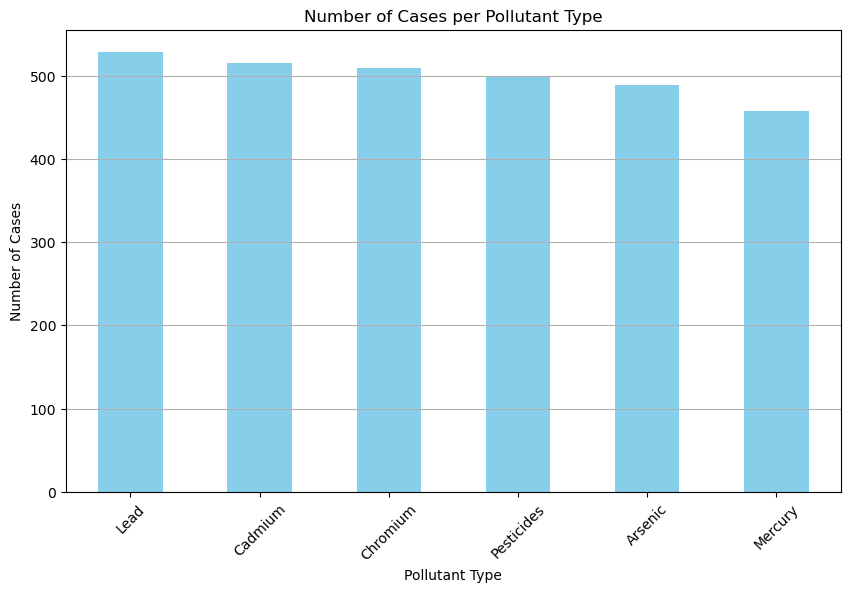

In [82]:
pollutant_counts = df['Pollutant_Type'].value_counts()
plt.figure(figsize=(10,6))
pollutant_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Cases per Pollutant Type')
plt.xlabel('Pollutant Type')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


Pie chart showing the percentage of cases by region.

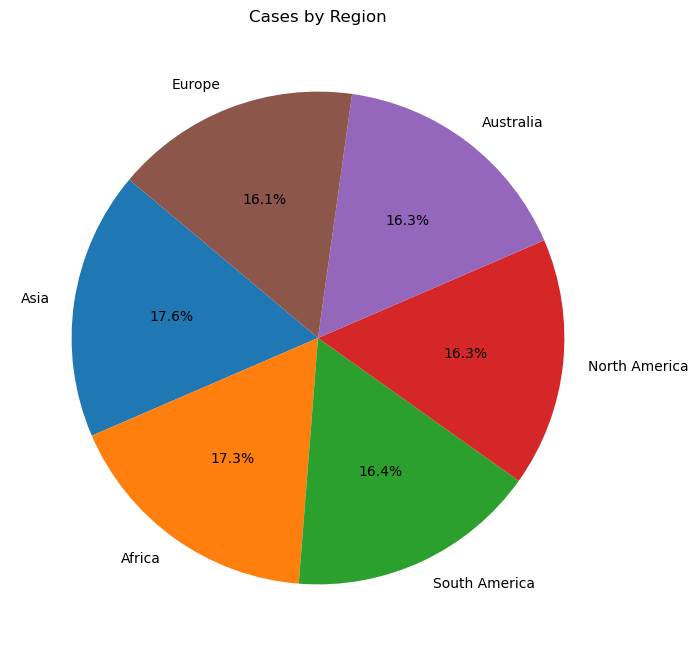

In [83]:
region_counts = df['Region'].value_counts()
plt.figure(figsize=(8,8))
region_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Cases by Region')
plt.ylabel('')
plt.show()


Plot a histogram of Soil pH values.

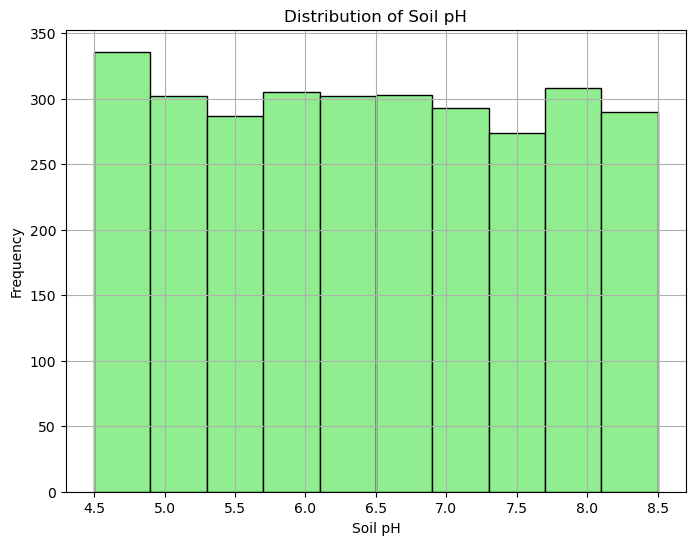

In [86]:
plt.figure(figsize=(8,6))
plt.hist(df['Soil_pH'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Distribution of Soil pH')
plt.xlabel('Soil pH')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


Compare average temperature for different soil textures using a bar chart.

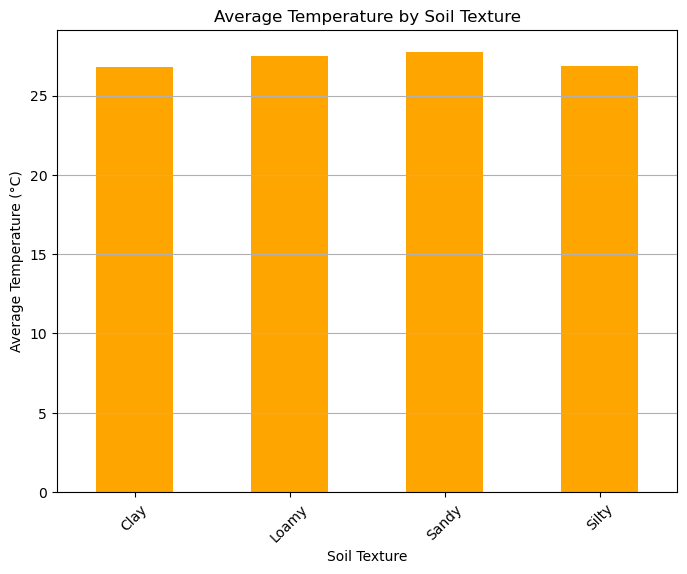

In [87]:
avg_temp_texture = df.groupby('Soil_Texture')['Temperature_C'].mean()
plt.figure(figsize=(8,6))
avg_temp_texture.plot(kind='bar', color='orange')
plt.title('Average Temperature by Soil Texture')
plt.xlabel('Soil Texture')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


Line chart showing number of cases reported each month.

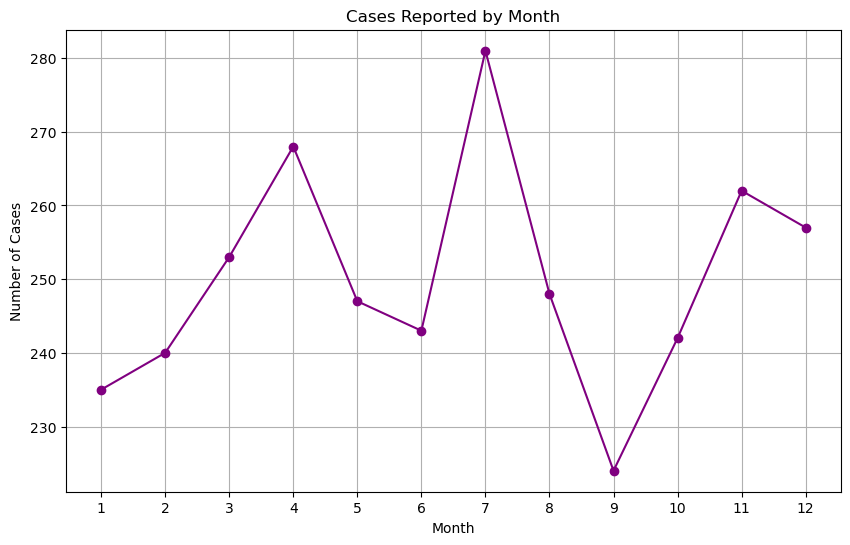

In [84]:
monthly_cases = df['Month'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.plot(monthly_cases.index, monthly_cases.values, marker='o', linestyle='-', color='purple')
plt.title('Cases Reported by Month')
plt.xlabel('Month')
plt.ylabel('Number of Cases')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()


Scatter plot: Pollutant Concentration vs Humidity.

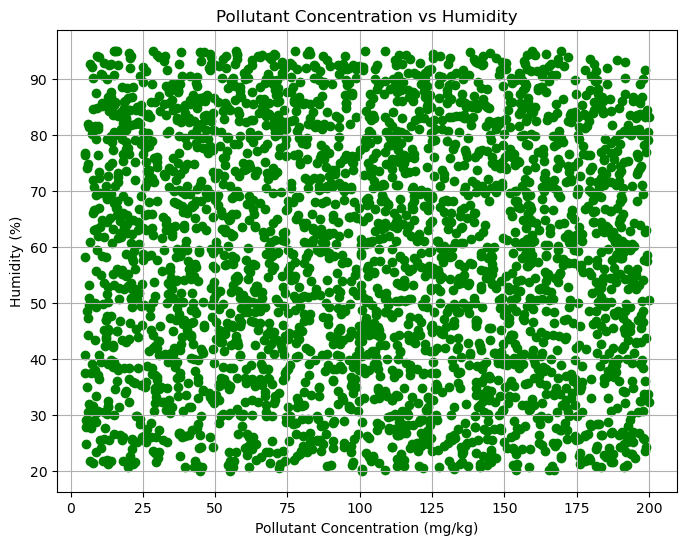

In [85]:
plt.figure(figsize=(8,6))
plt.scatter(df['Pollutant_Concentration_mg_kg'], df['Humidity_%'], color='green')
plt.title('Pollutant Concentration vs Humidity')
plt.xlabel('Pollutant Concentration (mg/kg)')
plt.ylabel('Humidity (%)')
plt.grid(True)
plt.show()


To summarize the dataset and provide future predictions, here is the analysis:

### Summary:
1. **Dataset Overview**:
    - The dataset contains 3000 records with 25 columns, capturing various attributes related to soil pollution, health impacts, and environmental factors.
    - Key columns include `Pollutant_Type`, `Disease_Type`, `Region`, `Country`, `Pollutant_Concentration_mg_kg`, and `Disease_Severity`.

2. **Key Insights**:
    - **Most Common Pollutant**: `Lead` is the most frequent pollutant with 529 cases.
    - **Most Affected Region**: `Asia` has the highest number of pollution cases.
    - **Most Common Disease for Lead Pollution**: `Respiratory Issues` are the most common health impact caused by lead.
    - **Most Affected Age Group**: The `Elderly` are the most affected age group.
    - **Country with Most Severe Cases**: `India` has the highest number of severe disease cases.

3. **Trends**:
    - Cases are distributed across all months, with the highest number of cases reported in July (281 cases).
    - The dataset shows a significant correlation between pollutant concentration and health impacts.

---

### Future Predictions:
1. **Increase in Pollution Cases**:
    - Based on the monthly distribution of cases, pollution cases may peak during the summer months (June to August) due to increased agricultural and industrial activities.

2. **Health Impacts**:
    - Regions with high pollutant concentrations, such as `Asia` and `Africa`, may see a rise in severe health issues like `Respiratory Issues` and `Neurological Disorders`.

3. **Mitigation Effectiveness**:
    - Countries implementing mitigation measures like `Soil Remediation` and `Government Regulation` may observe a gradual decline in pollution-related health cases.

4. **Focus on Lead Pollution**:
    - Since `Lead` is the most common pollutant, targeted efforts to reduce lead contamination in soil could significantly improve public health outcomes.

5. **Regional Focus**:
    - Regions like `Asia` and `Africa` should prioritize pollution control measures to mitigate the rising number of cases.
